In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [5]:
df = pd.read_csv("2024_Food_Establishment_Inspection_Scores_Edited.csv")
census = pd.read_csv("Census_Data.csv")

In [6]:
df["Inspection Date"] = pd.to_datetime(df["Inspection Date"], errors="coerce")
df["Inspection Year"] = df["Inspection Date"].dt.year
df["Zip Code"] = df["Zip Code"].astype(str).str.extract(r"(\d{5})")[0]
df["Score"] = pd.to_numeric(df["Score"], errors="coerce")
df = df.dropna(subset=["Inspection Year", "Zip Code", "Score"])
df["Inspection Year"] = df["Inspection Year"].astype(int)

In [7]:
zip_year = (
    df.groupby(["Zip Code", "Inspection Year"])
    .agg(
        avg_score=("Score", "mean"),
        num_inspections=("Score", "count"),
        score_std=("Score", "std")
    )
    .reset_index()
)
zip_year["score_std"] = zip_year["score_std"].fillna(0)

In [8]:
zip_year = zip_year.sort_values(["Zip Code", "Inspection Year"])
zip_year["previous_year_score"] = zip_year.groupby("Zip Code")["avg_score"].shift(1)
zip_year["two_year_avg_score"] = (
    zip_year.groupby("Zip Code")["avg_score"]
    .rolling(2)
    .mean()
    .reset_index(level=0, drop=True)
)
zip_year["score_change"] = zip_year["avg_score"] - zip_year["previous_year_score"]
zip_year = zip_year.dropna(subset=["previous_year_score", "two_year_avg_score"])

In [9]:
census["Zip Code"] = census["NAME"].astype(str).str.extract(r"(\d{5})")[0]
census_clean = census[[
    "Zip Code",
    "S1903_C03_001E",
    "S1903_C03_002E",
    "S1903_C03_003E",
    "S1903_C03_005E",
    "S1903_C03_009E",
    "S1903_C03_010E"
]].copy()
census_clean = census_clean.rename(columns={
    "S1903_C03_001E": "Median Household Income",
    "S1903_C03_002E": "White Median Income",
    "S1903_C03_003E": "Black Median Income",
    "S1903_C03_005E": "Asian Median Income",
    "S1903_C03_009E": "Hispanic Median Income",
    "S1903_C03_010E": "White Non-Hispanic Median Income"
})
for col in census_clean.columns:
    if col != "Zip Code":
        census_clean[col] = pd.to_numeric(census_clean[col], errors="coerce")

In [10]:
model_df = zip_year.merge(census_clean, on="Zip Code", how="left")

In [11]:
print(model_df.head())
print(model_df.columns)
print(model_df.isna().sum())

  Zip Code  Inspection Year  avg_score  num_inspections  score_std  \
0    78610             2024   98.00000                2   2.828427   
1    78610             2025   97.25000                4   2.061553   
2    78612             2025   83.50000                2   0.707107   
3    78613             2024   90.50000               12   8.867715   
4    78613             2025   89.71875               32   6.335941   

   previous_year_score  two_year_avg_score  score_change  \
0                 97.0           97.500000       1.00000   
1                 98.0           97.625000      -0.75000   
2                 76.0           79.750000       7.50000   
3                 90.3           90.400000       0.20000   
4                 90.5           90.109375      -0.78125   

   Median Household Income  White Median Income  Black Median Income  \
0                 119698.0             122538.0             123175.0   
1                 119698.0             122538.0             123175.0   
2 

In [12]:
target = "avg_score"
features = [
    "Zip Code",
    "Inspection Year",
    "num_inspections",
    "score_std",
    "previous_year_score",
    "two_year_avg_score",
    "score_change",
    "Median Household Income",
    "White Median Income",
    "Black Median Income",
    "Asian Median Income",
    "Hispanic Median Income",
    "White Non-Hispanic Median Income"
]
model_df = model_df.dropna(subset=features + [target])
X = model_df[features]
y = model_df[target]

In [13]:
train_df = model_df[model_df["Inspection Year"] <= 2025]
test_df = model_df[model_df["Inspection Year"] == 2026]
X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

In [14]:
categorical_features = ["Zip Code"]
numeric_features = [col for col in features if col not in categorical_features]
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            max_depth=8
        ))
    ]
)
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Zip Code']),
                                                 ('num', 'passthrough',
                                                  ['Inspection Year',
                                                   'num_inspections',
                                                   'score_std',
                                                   'previous_year_score',
                                                   'two_year_avg_score',
                                                   'score_change',
                                                   'Median Household Income',
                                                   'White Median Income',
                                                   'Black Median Income',
                                                   'Asian Median Income',
                                                   'Hispanic Median Income',
                                                   'White Non-Hispanic Median '
                                                   'Income'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=8, n_estimators=300,
                                       random_state=42))])

In [15]:
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.8236206612585644
RMSE: 1.183380173384449
R²: 0.6731924208446446


In [16]:
latest_year = model_df["Inspection Year"].max()
latest_data = model_df[model_df["Inspection Year"] == latest_year].copy()

prediction_2027 = latest_data.copy()
prediction_2027["Inspection Year"] = 2027

X_2027 = prediction_2027[features]

prediction_2027["Predicted_2027_Score"] = model.predict(X_2027)

In [17]:
results_2027 = prediction_2027[[
    "Zip Code",
    "Predicted_2027_Score",
    "previous_year_score",
    "two_year_avg_score",
    "num_inspections"
]].sort_values("Predicted_2027_Score")
print(results_2027)
results_2027.to_csv("predicted_inspection_scores_2027.csv", index=False)

    Zip Code  Predicted_2027_Score  previous_year_score  two_year_avg_score  \
39     78701             89.077433            89.280269           89.044482   
48     78704             89.078532            89.171206           87.161361   
5      78613             89.091011            89.718750           88.409375   
63     78722             89.208137            89.784314           89.058824   
126    78745             89.302205            89.356083           88.262947   
147    78752             89.344039            89.970238           89.402766   
42     78702             89.707746            88.867470           89.138653   
150    78753             89.709888            89.840970           89.489792   
81     78728             89.713137            92.813559           90.906780   
156    78756             89.747958            92.063830           90.402285   
132    78747             89.847712            89.857143           91.428571   
141    78750             89.858866            89.347

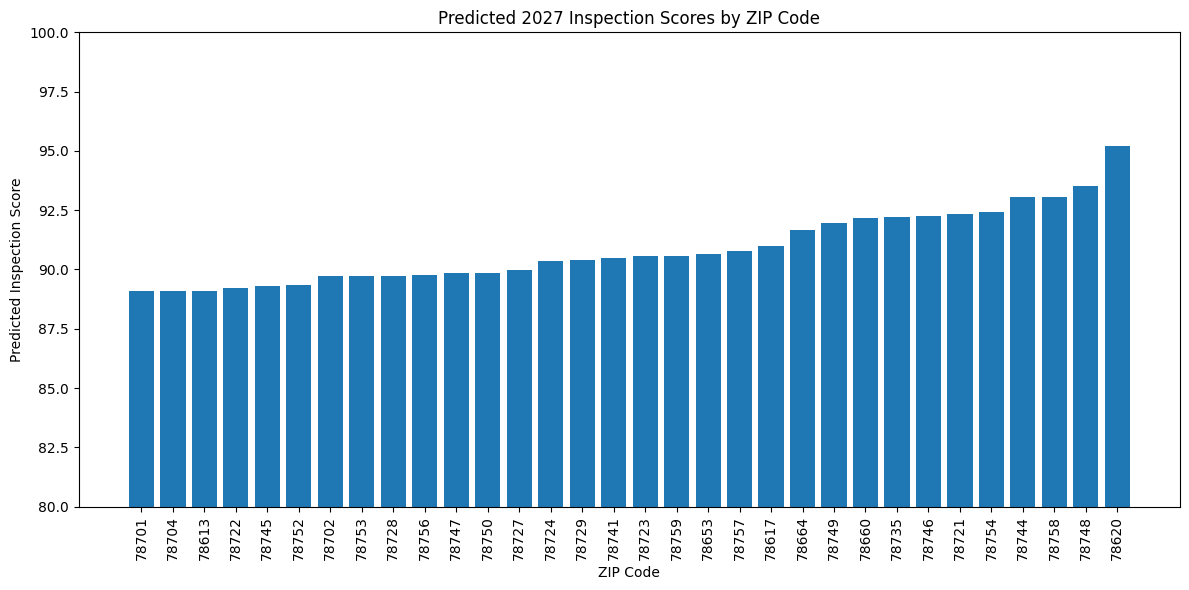

In [18]:
plot_df = results_2027.copy()
plot_df["Zip Code"] = plot_df["Zip Code"].astype(str)
plot_df["Predicted_2027_Score"] = pd.to_numeric(plot_df["Predicted_2027_Score"], errors="coerce")
plot_df = plot_df.dropna(subset=["Predicted_2027_Score"])
plot_df = plot_df.sort_values("Predicted_2027_Score")

plt.figure(figsize=(12, 6))
plt.bar(plot_df["Zip Code"], plot_df["Predicted_2027_Score"])
plt.ylim(80, 100)
plt.xticks(rotation=90)
plt.xlabel("ZIP Code")
plt.ylabel("Predicted Inspection Score")
plt.title("Predicted 2027 Inspection Scores by ZIP Code")
plt.tight_layout()
plt.show()